# A rede de saúde por habitante: leitos, UTI e médicos

**A pergunta:** um estado tem leitos suficientes? E eles estão onde as pessoas
estão? A resposta exige duas coisas que quase nunca aparecem juntas: o cadastro
da rede (CNES) e a população (IBGE). Este notebook junta as duas e chega aos
indicadores que planejamento de saúde usa de verdade.

**Fonte:** Cadastro Nacional de Estabelecimentos de Saúde (CNES/DATASUS) e
projeções do IBGE.

**Tempo estimado:** 5 a 8 minutos.

**O que você leva daqui:** leitos por mil habitantes por município e por região
de saúde, leitos de UTI por 100 mil, a medida de concentração da rede — e a
correção de um erro que aparece em quase toda notícia sobre "médicos por mil
habitantes".

In [2]:
%pip install pysus nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

print("Ambiente pronto.")

Ambiente pronto.


## 1. O que você pode trocar

In [4]:
UF = "PR"        # estado analisado
ANO = 2024       # ano da competência do CNES e da população
MES = 6          # mês da competência (o CNES é mensal)

UFS = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
    28: "SE", 29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP",
    41: "PR", 42: "SC", 43: "RS", 50: "MS", 51: "MT", 52: "GO", 53: "DF",
}
CODIGO_UF = {sigla: codigo for codigo, sigla in UFS.items()}
print(f"{UF}, competência {MES:02d}/{ANO}")

PR, competência 06/2024


## 2. O CNES não é uma base, são treze

Ao contrário das outras, esta base **exige** o parâmetro `group`. Sem ele, a
biblioteca baixa tudo junto: mais de 300 MB e 362 colunas com assuntos
misturados. Cada grupo é uma tabela diferente sobre a mesma rede.

In [5]:
from pysus import list_files

GRUPOS_CNES = {
    "LT": "Leitos — quantos, de que tipo, quantos são do SUS",
    "ST": "Estabelecimentos — o cadastro de cada unidade",
    "PF": "Profissionais — cada vínculo de trabalho",
    "EQ": "Equipamentos — tomógrafos, mamógrafos, respiradores",
    "SR": "Serviços especializados oferecidos",
    "HB": "Habilitações — o que a unidade está autorizada a fazer",
    "EP": "Equipes — Saúde da Família e outras",
    "IN": "Incentivos financeiros",
    "RC": "Regras contratuais",
    "DC": "Dados complementares",
    "EE": "Estabelecimentos de ensino",
    "EF": "Estabelecimentos filantrópicos",
    "GM": "Gestão e metas",
}

catalogo = list_files(dataset="cnes", state=UF, year=ANO)
catalogo["arquivo"] = [os.path.basename(str(n).replace("\\", "/"))
                       for n in catalogo["name"]]
catalogo["grupo"] = catalogo["arquivo"].str[:2].str.upper()

presentes = sorted(catalogo["grupo"].unique())
resumo = pd.DataFrame({
    "grupo": presentes,
    "o que traz": [GRUPOS_CNES.get(g, "") for g in presentes],
    "arquivos no ano": [int((catalogo["grupo"] == g).sum()) for g in presentes],
})
resumo

,grupo,o que traz,arquivos no ano
0,DC,Dados complementares,12
1,EF,Estabelecimentos filantrópicos,12
2,EP,Equipes — Saúde da Família e outras,12
3,EQ,"Equipamentos — tomógrafos, mamógrafos, respira...",12
4,GM,Gestão e metas,12
5,HB,Habilitações — o que a unidade está autorizada...,12
6,IN,Incentivos financeiros,12
7,LT,"Leitos — quantos, de que tipo, quantos são do SUS",12
8,PF,Profissionais — cada vínculo de trabalho,12
9,RC,Regras contratuais,12


## 3. Leitos: quantos existem e quantos são do SUS

Cada linha do grupo LT é uma combinação de estabelecimento e tipo de leito,
com a quantidade. Somar `QT_EXIST` dá o total; `QT_SUS` diz quantos estão
disponíveis para o SUS.

In [6]:
from pysus import cnes

arquivo_lt = cnes(UF, ANO, MES, group="LT")[0].replace("\\", "/")
leitos = con.execute(f"SELECT * FROM read_parquet('{arquivo_lt}')").df()

for coluna in ["QT_EXIST", "QT_SUS", "QT_CONTR", "QT_NSUS"]:
    leitos[coluna] = pd.to_numeric(leitos[coluna], errors="coerce").fillna(0)

total_leitos = int(leitos["QT_EXIST"].sum())
leitos_sus = int(leitos["QT_SUS"].sum())

print(f"Estabelecimentos com leitos: {mil(leitos['CNES'].nunique())}")
print(f"Leitos existentes:           {mil(total_leitos)}")
print(f"Leitos disponíveis ao SUS:   {mil(leitos_sus)} "
      f"({leitos_sus / total_leitos * 100:.1f}%)")

Estabelecimentos com leitos: 523
Leitos existentes:           31.125
Leitos disponíveis ao SUS:   21.537 (69.2%)


### Conferindo o significado de um código, de novo

O campo `TP_LEITO` classifica o leito em sete tipos, e vale entender o que cada
um agrupa antes de sair somando — sobretudo o tipo 3, o **complementar**.

Um aviso que evita um erro comum: complementar **não é sinônimo de UTI**. A
categoria reúne as unidades de terapia intensiva com as unidades
intermediárias e as de cuidados intermediários neonatais. Por isso ela pesa
mais que os 6% a 8% que a UTI sozinha costuma representar. Para isolar a UTI é
preciso descer ao código específico do leito (`CODLEITO`), cuja tabela de
significados não acompanha o arquivo.

In [7]:
TIPOS_LEITO = {
    "1": "Cirúrgico",
    "2": "Clínico",
    "3": "Complementar (UTI e unidades intermediárias)",
    "4": "Obstétrico",
    "5": "Pediátrico",
    "6": "Outras especialidades",
    "7": "Hospital-dia",
}

por_tipo = (
    leitos.assign(tipo=leitos["TP_LEITO"].astype(str).str.strip().map(TIPOS_LEITO))
    .groupby("tipo")
    .agg(**{"Leitos": ("QT_EXIST", "sum"), "Do SUS": ("QT_SUS", "sum")})
    .astype(int)
)
por_tipo["% do total"] = (por_tipo["Leitos"] / total_leitos * 100).round(1)
por_tipo["% para o SUS"] = (por_tipo["Do SUS"] / por_tipo["Leitos"] * 100).round(1)
por_tipo = por_tipo.sort_values("Leitos", ascending=False)

complementares = int(por_tipo.loc[TIPOS_LEITO["3"], "Leitos"])
print(f"Leitos complementares: {mil(complementares)} "
      f"({complementares / total_leitos * 100:.1f}% do total)")
print("Dentro deles convivem códigos de leito diferentes — UTI adulto, "
      "pediátrica,\nneonatal e unidades intermediárias:")
print(leitos[leitos["TP_LEITO"].astype(str).str.strip() == "3"]
      .groupby("CODLEITO")["QT_EXIST"].sum().nlargest(6).to_string())
print()
por_tipo

Leitos complementares: 4.221 (13.6% do total)
Dentro deles convivem códigos de leito diferentes — UTI adulto, pediátrica,
neonatal e unidades intermediárias:
CODLEITO
75    2047
81     454
76     432
66     285
92     203
74     157



,Leitos,Do SUS,% do total,% para o SUS
tipo,,,,
Clínico,9991,7534,32.1,75.4
Cirúrgico,7699,4736,24.7,61.5
Complementar (UTI e unidades intermediárias),4221,2688,13.6,63.7
Outras especialidades,3190,2433,10.2,76.3
Obstétrico,2758,1991,8.9,72.2
Pediátrico,2477,1975,8.0,79.7
Hospital-dia,789,180,2.5,22.8


Repare também na coluna da direita: a fatia destinada ao SUS **não é a mesma em
todos os tipos**. É nela que se lê a divisão do sistema — os leitos obstétricos
e pediátricos costumam ser majoritariamente públicos, enquanto os cirúrgicos
têm participação privada muito maior.

## 4. Leitos por mil habitantes

Agora o número que se compara com parâmetro. A Portaria GM/MS nº 1.101 de 2002
recomendava de **2,5 a 3 leitos por mil habitantes**. É um parâmetro antigo e
discutido, mas continua sendo a referência citada em quase todo plano estadual.

Antes de dividir, conferimos a integridade do arquivo de população — porque
alguns anos vêm truncados na origem.

In [8]:
from pysus import ibge

def populacao_municipal(ano):
    """População por município, com conferência de integridade.

    Recusa o arquivo se ele não tiver os 5.570 municípios em 27 UFs — 2022 e
    2023, por exemplo, vêm truncados na origem.
    """
    caminho = [c for c in ibge(year=ano)
               if os.path.basename(c).startswith("POPT")][0].replace("\\", "/")
    tabela = con.execute(f"SELECT * FROM read_parquet('{caminho}')").df()
    tabela["POPULACAO"] = pd.to_numeric(tabela["POPULACAO"], errors="coerce")
    tabela["UF"] = tabela["MUNIC_RES"].astype(str).str[:2].astype(int).map(UFS)
    if tabela["UF"].nunique() < 27 or len(tabela) < 5000:
        raise ValueError(
            f"O arquivo de população de {ano} está incompleto "
            f"({len(tabela)} municípios em {tabela['UF'].nunique()} UFs)."
        )
    return tabela

populacao = populacao_municipal(ANO)
populacao_uf = populacao[populacao["UF"] == UF].copy()
# o CNES usa o código de 6 dígitos; o IBGE, o de 7
populacao_uf["cod6"] = populacao_uf["MUNIC_RES"].astype(str).str[:6]

habitantes = int(populacao_uf["POPULACAO"].sum())
por_mil = total_leitos / habitantes * 1000
sus_por_mil = leitos_sus / habitantes * 1000
uti_por_cem_mil = complementares / habitantes * 100_000

print(f"População de {UF} em {ANO}: {mil(habitantes)}\n")
print(f"Leitos por mil habitantes:            {por_mil:.2f}")
print(f"Leitos SUS por mil habitantes:        {sus_por_mil:.2f}")
print(f"Leitos complementares por 100 mil:    {uti_por_cem_mil:.1f}")
print()
print("Parâmetros de referência:")
print("  Portaria GM/MS 1.101/2002: de 2,5 a 3,0 leitos por mil habitantes")
print("  UTI: de 10 a 30 por 100 mil — lembrando que o número acima inclui")
print("  também as unidades intermediárias, e por isso fica mais alto")

População de PR em 2024: 11.824.665

Leitos por mil habitantes:            2.63
Leitos SUS por mil habitantes:        1.82
Leitos complementares por 100 mil:    35.7

Parâmetros de referência:
  Portaria GM/MS 1.101/2002: de 2,5 a 3,0 leitos por mil habitantes
  UTI: de 10 a 30 por 100 mil — lembrando que o número acima inclui
  também as unidades intermediárias, e por isso fica mais alto


## 5. A rede não está onde as pessoas estão

A média do estado esconde o essencial. Leito de hospital é recurso concentrado:
a maioria dos municípios brasileiros não tem nenhum, e seus moradores dependem
de um vizinho maior. Ver isso município a município muda a conversa.

In [9]:
leitos_municipio = (
    leitos.groupby(leitos["CODUFMUN"].astype(str))
    .agg(**{"Leitos": ("QT_EXIST", "sum"), "Leitos SUS": ("QT_SUS", "sum"),
            "Estabelecimentos": ("CNES", "nunique")})
)

mapa = populacao_uf.set_index("cod6")[["POPULACAO"]].join(leitos_municipio, how="left")
mapa[["Leitos", "Leitos SUS", "Estabelecimentos"]] = (
    mapa[["Leitos", "Leitos SUS", "Estabelecimentos"]].fillna(0).astype(int))
mapa["Leitos por mil"] = (mapa["Leitos"] / mapa["POPULACAO"] * 1000).round(2)

sem_leitos = mapa[mapa["Leitos"] == 0]
print(f"Municípios do estado: {len(mapa)}")
print(f"Sem nenhum leito cadastrado: {len(sem_leitos)} "
      f"({len(sem_leitos) / len(mapa) * 100:.0f}%)")
print(f"População que vive neles: {mil(sem_leitos['POPULACAO'].sum())} "
      f"({sem_leitos['POPULACAO'].sum() / habitantes * 100:.1f}% do estado)")
print()
print("Os dez municípios com mais leitos:")
mapa.nlargest(10, "Leitos")[["POPULACAO", "Leitos", "Leitos SUS", "Leitos por mil"]]

Municípios do estado: 399
Sem nenhum leito cadastrado: 157 (39%)
População que vive neles: 1.307.879 (11.1% do estado)

Os dez municípios com mais leitos:


,POPULACAO,Leitos,Leitos SUS,Leitos por mil
cod6,,,,
410690,1829225,6153,3129,3.36
411370,577318,2458,1528,4.26
411520,425983,1758,841,4.13
410420,142695,1366,1292,9.57
410480,364104,1193,724,3.28
411990,372562,946,653,2.54
412810,121972,796,626,6.53
411950,124934,726,501,5.81
410830,295500,636,463,2.15


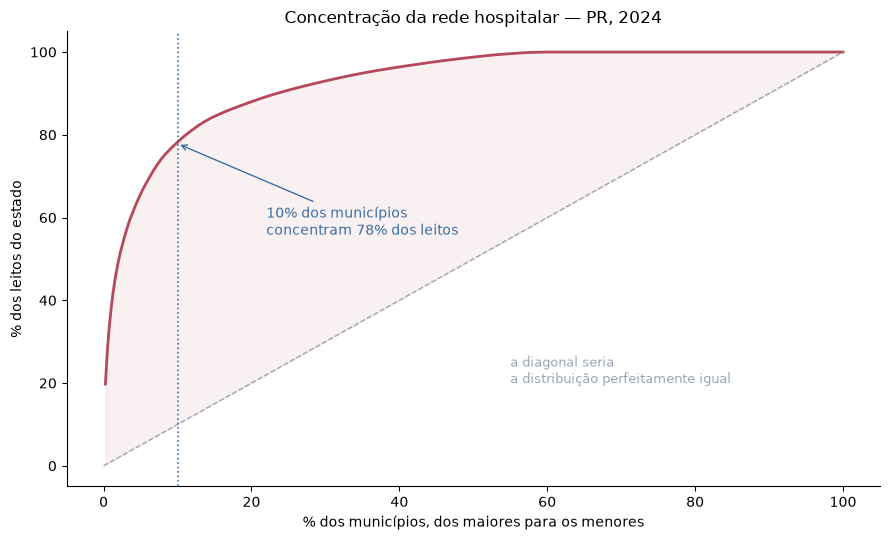

In [10]:
# Curva de concentração: que fatia dos leitos está nos maiores municípios.
ordenado = mapa.sort_values("Leitos", ascending=False)
acumulado_leitos = ordenado["Leitos"].cumsum() / total_leitos * 100
fatia_municipios = np.arange(1, len(ordenado) + 1) / len(ordenado) * 100

dez_por_cento = int(len(ordenado) * 0.1)
concentracao = acumulado_leitos.iloc[dez_por_cento - 1]

figura, eixo = plt.subplots(figsize=(9, 5.5))
eixo.plot(fatia_municipios, acumulado_leitos, color="#b5495b", linewidth=2)
eixo.plot([0, 100], [0, 100], color="#9aa5b1", linestyle="--", linewidth=1)
eixo.fill_between(fatia_municipios, fatia_municipios, acumulado_leitos,
                  color="#b5495b", alpha=0.08)

eixo.axvline(10, color="#3b6ea5", linestyle=":", linewidth=1.2)
eixo.annotate(f"10% dos municípios\nconcentram {concentracao:.0f}% dos leitos",
              xy=(10, concentracao), xytext=(22, concentracao - 22),
              arrowprops=dict(arrowstyle="->", color="#3b6ea5"),
              color="#3b6ea5", fontsize=10)

eixo.set_xlabel("% dos municípios, dos maiores para os menores")
eixo.set_ylabel("% dos leitos do estado")
eixo.set_title(f"Concentração da rede hospitalar — {UF}, {ANO}", fontsize=12)
eixo.text(55, 20, "a diagonal seria\na distribuição perfeitamente igual",
          color="#9aa5b1", fontsize=9)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Região de saúde: a unidade em que o planejamento acontece

Nenhum município pequeno precisa de UTI própria — precisa de acesso a uma. Por
isso o SUS organiza a assistência em **regiões de saúde**, e o CNES traz esse
código em cada registro. Agregar por região é a forma correta de perguntar se
falta leito.

Só que o campo vem sujo. Cada estabelecimento preencheu do seu jeito: a mesma
segunda regional aparece como `2ª`, `02`, `002` e `2`. Somar sem limpar
inventa regiões que não existem e reparte a população entre elas.

In [11]:
def regiao_limpa(valor):
    "Extrai o número da região de saúde, ignorando zeros e ordinais."
    digitos = "".join(c for c in str(valor) if c.isdigit())
    return f"{int(digitos):02d}" if digitos else None

antes = leitos["REGSAUDE"].astype(str).str.strip().nunique()
leitos["regiao"] = leitos["REGSAUDE"].map(regiao_limpa)
depois = leitos["regiao"].nunique()

print(f"Códigos distintos escritos no arquivo: {antes}")
print(f"Regiões de saúde de verdade:           {depois}")
print()
print("Exemplos do que estava escrito para a mesma região:")
amostra = (leitos.groupby("regiao")["REGSAUDE"]
           .apply(lambda s: sorted(set(s.astype(str).str.strip()))))
print(amostra[amostra.map(len) > 1].head(4).to_string())

Códigos distintos escritos no arquivo: 47
Regiões de saúde de verdade:           24

Exemplos do que estava escrito para a mesma região:
regiao
02    [002, 02, 2, 2ª, 2ºRS]
03              [003, 03, 3]
04                 [004, 04]
07               [07, 7, 7ª]


In [12]:
regioes = (
    leitos.dropna(subset=["regiao"]).groupby("regiao")
    .agg(**{"Leitos": ("QT_EXIST", "sum"), "Leitos SUS": ("QT_SUS", "sum"),
            "Municípios com leito": ("CODUFMUN", "nunique")})
    .astype(int)
)

# população de cada região, somando os municípios que a compõem
mapa_regiao = (
    leitos[["CODUFMUN", "regiao"]].astype(str).drop_duplicates()
    .rename(columns={"regiao": "REGSAUDE"})
)
populacao_regiao = (
    mapa_regiao.merge(populacao_uf[["cod6", "POPULACAO"]],
                      left_on="CODUFMUN", right_on="cod6")
    .drop_duplicates("CODUFMUN")
    .groupby("REGSAUDE")["POPULACAO"].sum()
)

regioes = regioes.join(populacao_regiao.rename("População"))
regioes["Leitos por mil"] = (regioes["Leitos"] / regioes["População"] * 1000).round(2)
regioes["SUS por mil"] = (regioes["Leitos SUS"] / regioes["População"] * 1000).round(2)
regioes = regioes.dropna(subset=["População"]).sort_values("Leitos por mil")

print(f"{len(regioes)} regiões de saúde com leitos cadastrados.\n")
print("As cinco com menos leitos por habitante:")
display(regioes.head(5))
print("\nAs cinco com mais:")
regioes.tail(5)

23 regiões de saúde com leitos cadastrados.

As cinco com menos leitos por habitante:


,Leitos,Leitos SUS,Municípios com leito,População,Leitos por mil,SUS por mil
regiao,,,,,,
01,322,221,6,280163.0,1.15,0.79
21,285,201,4,135915.0,2.10,1.48
09,899,484,6,425125.0,2.11,1.14
03,1339,1000,9,610934.0,2.19,1.64
20,845,493,12,385431.0,2.19,1.28



As cinco com mais:


,Leitos,Leitos SUS,Municípios com leito,População,Leitos por mil,SUS por mil
regiao,,,,,,
12,806,676,9,214237.0,3.76,3.16
16,1365,1170,10,334771.0,4.08,3.49
18,840,637,16,194286.0,4.32,3.28
22,486,434,9,106423.0,4.57,4.08
13,311,261,7,49699.0,6.26,5.25


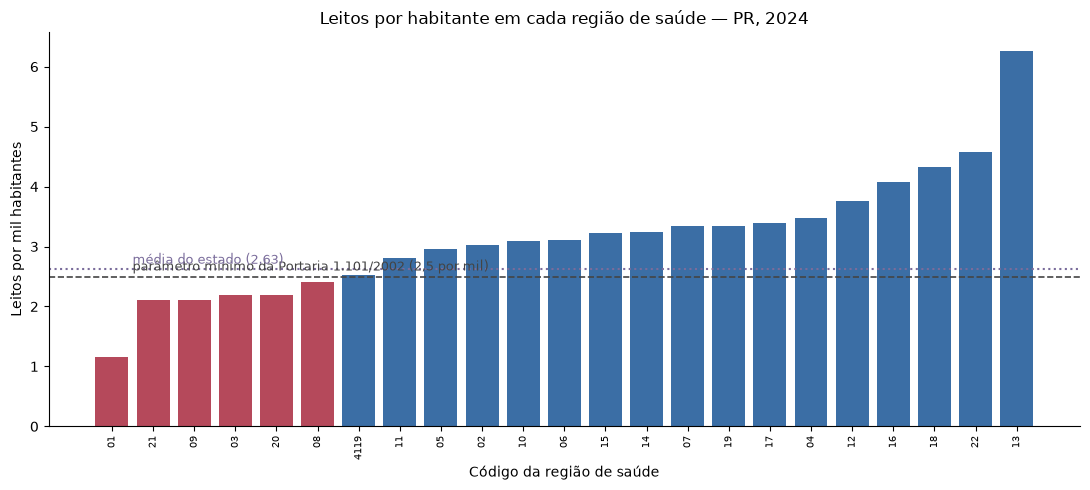

6 de 23 regiões estão abaixo do parâmetro mínimo, onde vivem 2.116.811 pessoas.


In [13]:
figura, eixo = plt.subplots(figsize=(11, 5))
cores = ["#b5495b" if v < 2.5 else "#3b6ea5" for v in regioes["Leitos por mil"]]
eixo.bar(range(len(regioes)), regioes["Leitos por mil"], color=cores)
eixo.axhline(2.5, color="#444", linestyle="--", linewidth=1.2)
eixo.text(0.5, 2.6, "parâmetro mínimo da Portaria 1.101/2002 (2,5 por mil)",
          fontsize=9, color="#444")
eixo.axhline(por_mil, color="#7a6c9b", linestyle=":", linewidth=1.5)
eixo.text(0.5, por_mil + 0.08, f"média do estado ({por_mil:.2f})",
          fontsize=9, color="#7a6c9b")

eixo.set_xticks(range(len(regioes)))
eixo.set_xticklabels(regioes.index, rotation=90, fontsize=7)
eixo.set_ylabel("Leitos por mil habitantes")
eixo.set_xlabel("Código da região de saúde")
eixo.set_title(f"Leitos por habitante em cada região de saúde — {UF}, {ANO}",
               fontsize=12)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

abaixo = (regioes["Leitos por mil"] < 2.5).sum()
print(f"{abaixo} de {len(regioes)} regiões estão abaixo do parâmetro mínimo, "
      f"onde vivem {mil(regioes[regioes['Leitos por mil'] < 2.5]['População'].sum())} pessoas.")

## 7. Profissionais: o erro que quase toda notícia comete

O grupo PF tem uma linha por **vínculo de trabalho**, não por pessoa. Um médico
que atende em três lugares aparece três vezes. Contar linhas e dividir pela
população produz um número inflado — e é exatamente assim que costuma ser
publicado.

O arquivo traz um identificador do profissional, o que permite contar pessoas.
A diferença entre as duas contas é grande.

In [14]:
arquivo_pf = cnes(UF, ANO, MES, group="PF")[0].replace("\\", "/")

vinculos = con.execute(f"SELECT count(*) FROM read_parquet('{arquivo_pf}')").fetchone()[0]
pessoas = con.execute(
    f"SELECT count(DISTINCT CPF_PROF) FROM read_parquet('{arquivo_pf}')").fetchone()[0]

print(f"Vínculos de trabalho cadastrados: {mil(vinculos)}")
print(f"Profissionais distintos:          {mil(pessoas)}")
print(f"Vínculos por profissional:        {vinculos / pessoas:.2f}")
print()
print("O identificador vem embaralhado no arquivo público — não permite")
print("identificar ninguém, mas é constante, e isso basta para contar pessoas.")

Vínculos de trabalho cadastrados: 351.247
Profissionais distintos:          226.387
Vínculos por profissional:        1.55

O identificador vem embaralhado no arquivo público — não permite
identificar ninguém, mas é constante, e isso basta para contar pessoas.


In [15]:
# Na CBO 2002, as famílias 2251, 2252 e 2253 são médicos; 2235, enfermeiros.
CATEGORIAS = {
    "Médicos": ("225",),
    "Enfermeiros": ("2235",),
    "Cirurgiões-dentistas": ("2232",),
    "Técnicos e auxiliares de enfermagem": ("3222", "5152"),
    "Agentes comunitários de saúde": ("5151",),
    "Fisioterapeutas": ("2236",),
    "Psicólogos": ("2515",),
    "Farmacêuticos": ("2234",),
}

condicoes = []
for nome, prefixos in CATEGORIAS.items():
    teste = " OR ".join(f"CBO LIKE '{p}%'" for p in prefixos)
    condicoes.append(f"WHEN {teste} THEN '{nome}'")
regra = "CASE " + " ".join(condicoes) + " ELSE 'Outras ocupações' END"

profissionais = con.execute(f"""
    SELECT {regra} AS categoria,
           count(*) AS vinculos,
           count(DISTINCT CPF_PROF) AS pessoas,
           sum(CASE WHEN PROF_SUS = '1' THEN 1 ELSE 0 END) AS vinculos_sus
    FROM read_parquet('{arquivo_pf}')
    GROUP BY 1
""").df().set_index("categoria")

profissionais["Por mil habitantes"] = (
    profissionais["pessoas"] / habitantes * 1000).round(2)
profissionais["Vínculos por pessoa"] = (
    profissionais["vinculos"] / profissionais["pessoas"]).round(2)
profissionais["% dos vínculos no SUS"] = (
    profissionais["vinculos_sus"] / profissionais["vinculos"] * 100).round(1)
profissionais = profissionais.sort_values("pessoas", ascending=False)

profissionais[["pessoas", "vinculos", "Vínculos por pessoa",
               "Por mil habitantes", "% dos vínculos no SUS"]]

,pessoas,vinculos,Vínculos por pessoa,Por mil habitantes,% dos vínculos no SUS
categoria,,,,,
Outras ocupações,73508,82368,1.12,6.22,77.3
Técnicos e auxiliares de enfermagem,52809,62242,1.18,4.47,88.0
Médicos,32785,116693,3.56,2.77,64.6
Enfermeiros,20930,26606,1.27,1.77,90.0
Agentes comunitários de saúde,19374,19470,1.00,1.64,97.2
Cirurgiões-dentistas,10713,15142,1.41,0.91,39.8
Farmacêuticos,8322,10186,1.22,0.70,53.6
Fisioterapeutas,7403,9842,1.33,0.63,59.3
Psicólogos,6994,8698,1.24,0.59,49.0


In [16]:
medicos = profissionais.loc["Médicos"]
inflado = medicos["vinculos"] / habitantes * 1000

print("Médicos por mil habitantes\n")
print(f"  contando vínculos (errado):   {inflado:.2f}")
print(f"  contando pessoas (correto):   {medicos['Por mil habitantes']:.2f}")
print(f"  diferença:                    {inflado / medicos['Por mil habitantes']:.1f} vezes")
print()
print("Referência: o Conselho Federal de Medicina apura cerca de 2,8 médicos")
print("por mil habitantes no Brasil, com variação de 1,2 a 6 entre estados.")
print()
print("Uma ressalva honesta: o CNES conta quem está cadastrado em algum")
print("estabelecimento, e não distingue carga horária. Um plantonista de fim de")
print("semana pesa igual a um médico de quarenta horas — por isso o número")
print("serve para comparar regiões, não para dimensionar equipe.")

Médicos por mil habitantes

  contando vínculos (errado):   9.87
  contando pessoas (correto):   2.77
  diferença:                    3.6 vezes

Referência: o Conselho Federal de Medicina apura cerca de 2,8 médicos
por mil habitantes no Brasil, com variação de 1,2 a 6 entre estados.

Uma ressalva honesta: o CNES conta quem está cadastrado em algum
estabelecimento, e não distingue carga horária. Um plantonista de fim de
semana pesa igual a um médico de quarenta horas — por isso o número
serve para comparar regiões, não para dimensionar equipe.


Municípios sem nenhum médico cadastrado: 0
Municípios com menos de 1 médico por mil habitantes: 25



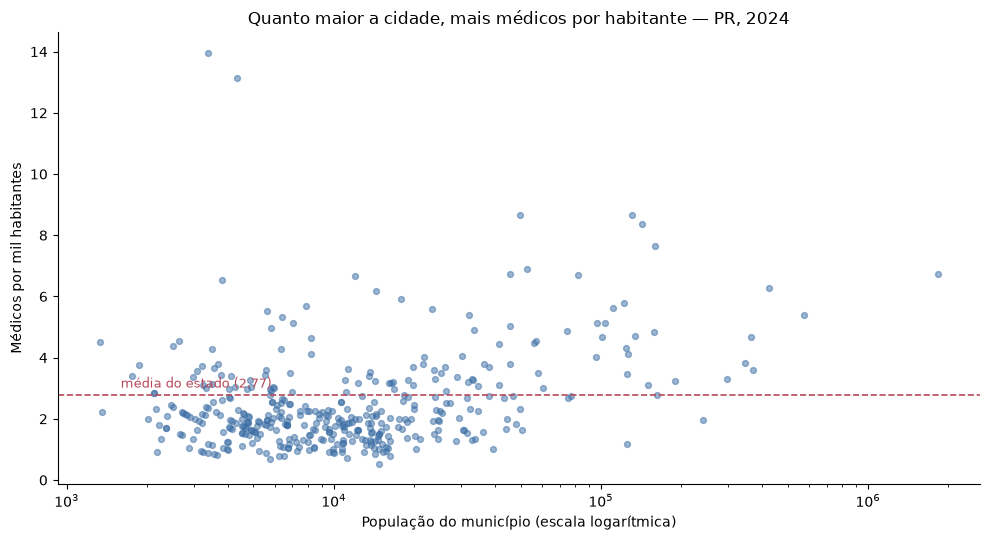

In [17]:
por_municipio = con.execute(f"""
    SELECT CODUFMUN AS cod6,
           count(DISTINCT CASE WHEN CBO LIKE '225%' THEN CPF_PROF END) AS medicos,
           count(DISTINCT CASE WHEN CBO LIKE '2235%' THEN CPF_PROF END) AS enfermeiros
    FROM read_parquet('{arquivo_pf}')
    GROUP BY 1
""").df().set_index("cod6")

mapa = mapa.join(por_municipio)
mapa[["medicos", "enfermeiros"]] = mapa[["medicos", "enfermeiros"]].fillna(0).astype(int)
mapa["Médicos por mil"] = (mapa["medicos"] / mapa["POPULACAO"] * 1000).round(2)

sem_medico = mapa[mapa["medicos"] == 0]
print(f"Municípios sem nenhum médico cadastrado: {len(sem_medico)}")
print(f"Municípios com menos de 1 médico por mil habitantes: "
      f"{(mapa['Médicos por mil'] < 1).sum()}")
print()

figura, eixo = plt.subplots(figsize=(10, 5.5))
com_dados = mapa[mapa["POPULACAO"] > 0]
eixo.scatter(com_dados["POPULACAO"], com_dados["Médicos por mil"],
             s=18, alpha=0.5, color="#3b6ea5")
eixo.set_xscale("log")
eixo.axhline(medicos["Por mil habitantes"], color="#b5495b",
             linestyle="--", linewidth=1.2)
eixo.text(mapa["POPULACAO"].min() * 1.2, medicos["Por mil habitantes"] + 0.25,
          f"média do estado ({medicos['Por mil habitantes']:.2f})",
          color="#b5495b", fontsize=9)
eixo.set_xlabel("População do município (escala logarítmica)")
eixo.set_ylabel("Médicos por mil habitantes")
eixo.set_title(f"Quanto maior a cidade, mais médicos por habitante — {UF}, {ANO}",
               fontsize=12)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

O gráfico mostra a lei mais teimosa da geografia da saúde: a densidade de
profissionais **cresce com o tamanho da cidade**. Não é apenas concentração de
hospitais — é onde as pessoas escolhem morar e trabalhar. Qualquer política de
provimento (Mais Médicos e sucessores) existe para mexer nessa nuvem de pontos.

## 8. Conferindo com a realidade

In [18]:
print("Verificações de sanidade\n")
print(f"1. Leitos por mil entre 1,5 e 4,0?          {por_mil:.2f} "
      f"({'sim' if 1.5 < por_mil < 4.0 else 'ATENÇÃO'})")
print(f"2. Complementares entre 8% e 18% do total?  "
      f"{complementares / total_leitos * 100:.1f}% "
      f"({'sim' if 8 < complementares / total_leitos * 100 < 18 else 'ATENÇÃO'})")
print(f"3. Médicos por mil entre 1,0 e 5,0?         "
      f"{medicos['Por mil habitantes']:.2f} "
      f"({'sim' if 1.0 < medicos['Por mil habitantes'] < 5.0 else 'ATENÇÃO'})")
print(f"4. Mais técnicos de enfermagem que médicos? "
      f"{'sim' if profissionais.loc['Técnicos e auxiliares de enfermagem', 'pessoas'] > medicos['pessoas'] else 'ATENÇÃO'}")
print(f"5. Leitos SUS entre 50% e 90% do total?     "
      f"{leitos_sus / total_leitos * 100:.1f}% "
      f"({'sim' if 50 < leitos_sus / total_leitos * 100 < 90 else 'ATENÇÃO'})")

Verificações de sanidade

1. Leitos por mil entre 1,5 e 4,0?          2.63 (sim)
2. Complementares entre 8% e 18% do total?  13.6% (sim)
3. Médicos por mil entre 1,0 e 5,0?         2.77 (sim)
4. Mais técnicos de enfermagem que médicos? sim
5. Leitos SUS entre 50% e 90% do total?     69.2% (sim)


## 9. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outro estado | `UF = "MA"` |
| Outra competência | `ANO` e `MES` — o CNES é mensal |
| Equipamentos (tomógrafo, mamógrafo) | `cnes(UF, ANO, MES, group="EQ")` |
| Equipes de Saúde da Família | `group="EP"` |
| Só hospitais | filtre `TP_UNID` no grupo `ST` |
| Outra ocupação | acrescente o prefixo da CBO em `CATEGORIAS` |
| Série no tempo | rode o notebook em laço sobre vários `ANO` e compare |

### O que vale levar

`populacao_municipal(ano)` — o denominador com conferência de integridade.
`regiao_limpa(valor)` — o campo de região de saúde vem escrito de várias
formas, e sem normalizar as contas se espalham por regiões inexistentes.
A distinção entre **vínculo** e **pessoa** — é ela que separa um número
publicável de um número inflado em uma vez e meia.

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Dados: CNES/DATASUS e IBGE, via biblioteca [PySUS](https://github.com/AlertaDengue/PySUS).
Notebook executado de verdade antes de publicado.*